# Surge Pricing Strategy Analysis

### An observational business analytics project on pricing, demand, and revenue trade-offs in ride-sharing data.


- This project analyzes how surge pricing is associated with observed ride volume, average price, and total revenue in a ride-sharing dataset.

- The goal is to investigate whether higher surge multipliers lead to higher overall revenue, or whether increased prices are offset by lower ride volume.

- This is an observational business analytics project, not a randomized A/B test.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt


## Dataset

- The dataset contains Uber and Lyft ride records, including ride price, distance, time, location, cab type, surge multiplier, and matched hourly weather information.

- Although this dataset can also be used for price prediction, this project focuses on surge pricing strategy and the 
relationship between pricing, observed demand, and revenue.

In [27]:
df = pd.read_csv("../data/rideshare_kaggle.csv")
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [28]:
df.shape

(693071, 57)

In [29]:
## Acquiring the data information about the columns.

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  str    
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  str    
 6   timezone                     693071 non-null  str    
 7   source                       693071 non-null  str    
 8   destination                  693071 non-null  str    
 9   cab_type                     693071 non-null  str    
 10  product_id                   693071 non-null  str    
 11  name                         693071 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


In [30]:
## Check if there are any missing values in this dataset.

print(df.isnull().sum())

id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime                       0
v

In [31]:
# Missing value summary
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]

missing_summary.sort_values(by="missing_count", ascending=False)

,missing_count,missing_percent
price,55095,7.949402


In [32]:
## Check if there are any duplicated rows in this dataset.

print(df.duplicated().sum())

0


In [33]:
## Listing out the avg. price for each surge multiplier.

df.groupby('surge_multiplier')['price'].mean()

surge_multiplier
1.00    16.161259
1.25    23.768471
1.50    28.894472
1.75    33.673760
2.00    39.048459
2.50    30.207792
3.00    40.333333
Name: price, dtype: float64

<Axes: >

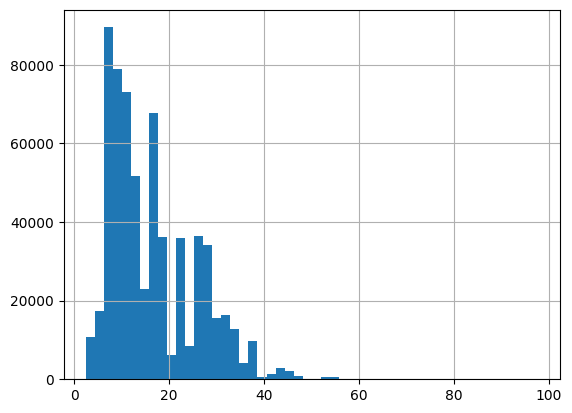

In [35]:
## Visualize the distribution of the price column.

df['price'].hist(bins=50)

<Axes: >

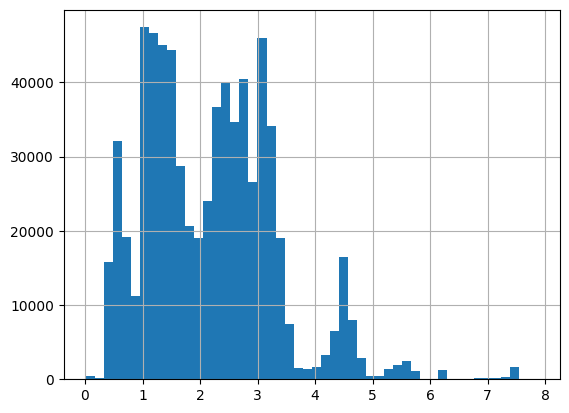

In [36]:
## Visualize the distribution of the distance column.

df['distance'].hist(bins=50)

In [37]:
## Check the range of the datetime column.

df["datetime"] = pd.to_datetime(df["datetime"])

print("Earliest datetime:", df["datetime"].min())
print("Latest datetime:", df["datetime"].max())

print("Time span:", df["datetime"].max() - df["datetime"].min())

Earliest datetime: 2018-11-26 03:40:46
Latest datetime: 2018-12-18 19:15:10
Time span: 22 days 15:34:24


In [39]:
## Finding out the surge multiplier distribution for the missing price values.

df[df['price'].isnull()]['surge_multiplier'].value_counts()


surge_multiplier
1.0    55095
Name: count, dtype: int64

### Initial Observations

- The dataset spans approximately **22 days**, covering ride activity from 2018/11/26 to 2018/12/18.

- The original dataset contains approximately **693k rows** and **57 features**.

- **No** duplicate rows were found, suggesting **good overall** data integrity.

- Missing values **only** appear in the **`price`** column, with **55,095** missing records, accounting for approximately 7.95% of the dataset.

- Since `price` is the key variable for this pricing analysis, rows with missing `price` values were **removed** before conducting price-related EDA.

- Dropping these rows reduces the number of non-surge observations, but it avoids introducing artificial fare values through imputation.

**Insight:**

- Missing values are only found in the `price` column.

- All missing `price` records occur when `surge_multiplier = 1.0`, meaning they are concentrated in non-surge rides.

- Since `price` is the key variable for this project, these rows cannot support pricing analysis and were removed before EDA.

- Dropping these rows may reduce the number of non-surge observations, but it avoids introducing artificial fare values through imputation.

In [40]:
## !!! Dropping the rows with missing price values since they only account for a small percentage of 
## the dataset and we cannot impute them without additional information.

df = df.dropna(subset=['price'])

## Demand Proxy

Because the dataset only contains completed ride records, it does not capture total user searches, ride requests, abandoned bookings, or conversion rates. Therefore, ride count is used as a proxy for observed demand, not true market demand.

## Surge Pricing Performance Summary

#### P.S. Total Revenue = Price × Number of Completed Rides

In [49]:
summary = df.groupby('surge_multiplier').agg(
    demand=('price', 'count'),
    revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    distance=('distance', 'mean')
).reset_index()

summary

,surge_multiplier,demand,revenue,avg_price,distance
0,1.00,617001,9971512.98,16.161259,2.184048
1,1.25,11085,263473.50,23.768471,2.277402
2,1.50,5065,146350.50,28.894472,2.424028
3,1.75,2420,81490.50,33.673760,2.410640
4,2.00,2239,87429.50,39.048459,2.389549
5,2.50,154,4652.00,30.207792,2.545325
6,3.00,12,484.00,40.333333,3.110000


This table shows that higher surge multipliers are associated with higher average prices, but sharply lower observed ride volume. In this dataset, total observed revenue is highest when the surge multiplier is 1.0.

### Surge Pricing vs Demand

- As surge multiplier increases, the number of rides **decreases significantly**.

- Majority of rides occur at **surge = 1.0**.

- High surge levels (e.g., 2.5+) have **extremely low** ride counts (154).


**Insight:**

- Indicates **strong** price sensitivity

- Suggests a **trade-off** between higher price and reduced demand

- Average distance **slightly** increases with surge multiplier

### Revenue Analysis

- The highest observed total revenue occurs when `surge_multiplier = 1.0`.

- Higher surge multipliers are associated with **lower** completed ride volume.

- Although average price increases under surge pricing, the decline in observed ride volume is **large enough** that total observed revenue **decreases** at higher surge levels.

**Insight:**

- Revenue in this dataset appears to be driven **more** by completed ride volume than by higher price per ride.

- **Aggressive** surge multipliers may **reduce** observed ride volume enough to offset the benefit of higher prices.

- This suggests that pricing strategy should **balance** price increases with demand retention.

### Pricing Recommendation

- The analysis suggests that aggressive surge pricing **(e.g., >1.5x)** significantly reduces demand and overall revenue.

- A moderate pricing strategy **(slightly more than 1.0)** may better balance demand and pricing power.

- This indicates that maximizing revenue requires optimizing for demand elasticity rather than simply increasing prices.

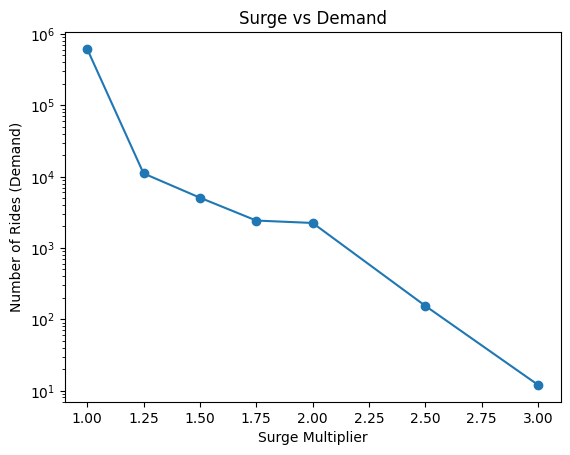

In [46]:
plt.plot(summary['surge_multiplier'], summary['demand'], marker='o')
plt.xlabel('Surge Multiplier')
plt.ylabel('Number of Rides (Demand)')
plt.title('Surge vs Demand')
plt.yscale('log')
plt.show()


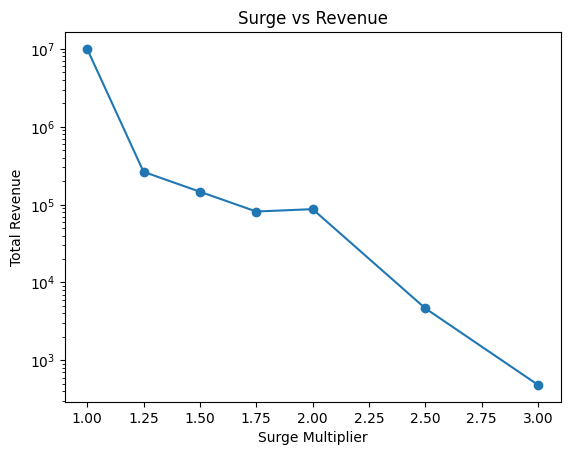

In [47]:
plt.plot(summary['surge_multiplier'], summary['revenue'], marker='o')
plt.xlabel('Surge Multiplier')
plt.ylabel('Total Revenue')
plt.title('Surge vs Revenue')
plt.yscale('log')
plt.show()

- Demand **drops sharply** as surge increases

- Revenue peaks at surge = **1.0**

- Higher surge levels lead to **significant** revenue decline

- Although the demand and revenue curves show similar downward patterns, they represent **different metrics**. Demand measures ride volume, while revenue measures total dollar value. The similar shape suggests that total revenue is largely driven by ride volume in this dataset.

## Optimization Perspective

- The goal is to maximize revenue while considering demand elasticity.

- Findings suggest that aggressive surge pricing reduces demand disproportionately, leading to lower overall revenue.

- Therefore, optimal pricing likely lies in a moderate surge range rather than extreme values.

In [15]:
best_strategy = summary.loc[summary["revenue"].idxmax()]
best_strategy

surge_multiplier    1.000000e+00
demand              6.170010e+05
revenue             9.971513e+06
avg_price           1.616126e+01
Name: 0, dtype: float64

Based on observed total revenue, the best-performing surge multiplier in this dataset is 1.0. This does not mean surge pricing is never useful, but it suggests that aggressive surge levels are associated with lower observed ride volume and lower total revenue in this dataset.

## Unit Economics

In [28]:
summary['avg_price'] = summary['revenue'] / summary['demand']

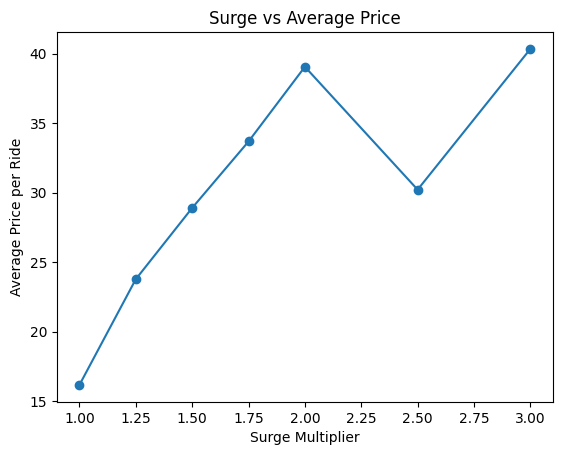

In [29]:
plt.plot(summary['surge_multiplier'], summary['avg_price'], marker='o')
plt.xlabel('Surge Multiplier')
plt.ylabel('Average Price per Ride')
plt.title('Surge vs Average Price')
plt.show()

- Although surge pricing increases the average price per ride, it leads to a **sharp** decline in demand, ultimately reducing total revenue. 

- Aggressive surge levels appear less effective in this dataset because the gain in average price does not offset the drop in observed ride volume.

- The variability at higher surge levels may be due to limited sample size.


### Final Conclusion

This project analyzes the observed relationship between surge pricing, completed ride volume, average price, and total observed revenue in a ride-sharing dataset.

**Key findings:**

- Completed ride volume decreases **sharply** as surge multiplier increases, suggesting strong price sensitivity in observed rides.

- Surge pricing increases the average price per ride, but the price increase is **not** sufficient to offset the decline in completed ride volume.

- As a result, total observed revenue is **highest** at `surge_multiplier = 1.0` and declines at higher surge levels.

**From a business perspective:**

- Revenue is primarily driven by completed ride volume, not only by price increases.

- Extreme surge levels are associated with much **lower** observed ride volume and lower total observed revenue.

- Therefore, extreme surge pricing **does not** appear to be revenue-optimal in this observed dataset.

### Recommendation

- A moderate pricing strategy may be more effective in **balancing price and observed demand**. Instead of maximizing price per ride, the platform should consider optimizing overall revenue by maintaining sufficient ride volume.

- This highlights the importance of considering **demand elasticity** when designing dynamic pricing systems.
